# LSN-0.3 — Statistics II: Probability, Conditioning, Correlation ≠ Causation

| | |
|---|---|
| **Lesson** | `LSN-0.3` — Module `MOD-0` (Foundations), Week 1 |
| **Serves** | `OUT-0.3` — *"how reliable is this answer, on what data?"* · `OUT-0.4` — *spot correlation-vs-causation and small-sample traps in a client's claim* |
| **Duration** | 90 min session (25 + 25 + 20 + 20) + 30 min pre-work |
| **Verified by** | `ASM-0` — scenario questions, not definitions |
| **Lesson plan** | `program/lessons/LSN-0.3-statistics-2-probability-correlation-causation.md` |

**The two misconceptions this session kills:**

1. that *"99% accurate"* means an alert is 99% likely to be real — that confuses **P(alert | fraud)** with
   **P(fraud | alert)**, and below those two differ by a factor of **101**;
2. that a chart moving with revenue **proves** the feature caused the revenue.

Every model output you will ever read is a **conditional probability** — conditional on inputs, and on
training data you have to ask about. That is the session.

**How to run this notebook.** Launch Jupyter from the repo root with the `LSN-0.1` venv active, then
`Run → Run All Cells`. It runs top to bottom with no arguments and no network; every number below is
computed from seeded data, so your output matches the room's.

```
source .venv/bin/activate
jupyter notebook notebooks/lessons/LSN-0.3_Statistics_2_Probability_Correlation_Causation.ipynb
```

**Order of business:**

1. **Pre-work — before the session** (~30 min): the 3Blue1Brown video, then fill in the base-rate fraud
   counts table in the cell below. It gets checked live at the top of segment 2.
2. **Session** — four segments, in order, matching the lesson plan: conditioning via fraud (25 min) →
   base rates on screen (25 min) → correlation vs causation (20 min) → the revenue-chart drill (20 min).
3. **Homework** — three scenario questions, graded pass/fail. Saves to `outputs/lsn-0.3/`, feeds `ASM-0`.

Fill-in cells never crash the notebook — they tell you what is still missing and wait for you.

> **Carried forward from `LSN-0.2`:** *how many, and collected how?* Today adds the third question —
> **conditional on what?** — and `LSN-1.3` gives today's headline fraction its formal name.

## Setup — imports, palette, seeds

Three rules this notebook obeys, so your numbers and the projector's agree:

- **Everything is seeded.** Each demo makes its own generator with its own seed, so you can re-run any
  single cell in any order and get the same picture back.
- **Every chart uses the VSP palette**, drops its top/right spines, and labels its axes.
- **Core stack only** (`numpy`, `pandas`, `matplotlib`, `seaborn`). Nothing heavier is installed until
  Week 2 — and nothing heavier is needed: most of this session is counting.

In [1]:
# numpy (arrays, distributions, correlations)
import numpy as np
# pandas (the counts tables — this lesson is mostly tables of counts)
import pandas as pd
# matplotlib (every chart in this notebook)
import matplotlib.pyplot as plt
# seaborn (the scatter with a categorical hue in segment 3)
import seaborn as sns
# stdlib math (erf: the normal CDF for the threshold sweep — there is no scipy in this venv)
from math import erf, sqrt
# stdlib pathlib (locate the repo root without hardcoding a path)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, bar edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      — primary series
    "green":  "#65a74e",  # green           — second series
    "yellow": "#ffe86b",  # yellow          — highlight (always with a dark edge)
    "mint":   "#97f377",  # green-lightest  — third series
    "ink":    "#2b374d",  # navy-darkest    — lines, edges, text
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found — are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())

print(f"numpy {np.__version__} · pandas {pd.__version__} · seaborn {sns.__version__}")
print(f"Repo root : {REPO_ROOT}")
print("[PASS] Setup complete — core stack only, palette loaded, paths resolved.")

numpy 2.5.1 · pandas 3.0.5 · seaborn 0.13.2
Repo root : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
[PASS] Setup complete — core stack only, palette loaded, paths resolved.


---

# Pre-work — do this **before** the session

*30 minutes total. No pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Watch **3Blue1Brown** — *"The medical test paradox, and redesigning Bayes' rule"* (`https://www.youtube.com/watch?v=lG4VkPoG3ko`) | 21 min | **One written answer:** a test catches 99% of cases — why isn't a positive result 99% proof you're sick? |
| 2 | Work the **base-rate fraud one-pager** — the cell below — filling in the counts table for 1,000,000 transactions | 9 min | **The completed counts table** — checked live in segment 2 |

*(Optional reinforcement, not required: StatQuest with Josh Starmer, "Conditional Probability, Clearly
Explained" — `youtube.com/@statquest`.)*

### The one-pager

A payments client runs a fraud detector. Three facts, and they are all you need:

- the detector **catches 99% of fraud** — of the transactions that really are fraud, 99 in 100 raise an
  alert;
- it has a **1% false-positive rate** — of the transactions that are perfectly legitimate, 1 in 100 raises
  an alert anyway;
- fraud occurs in **1 out of every 10,000 transactions**.

Now push **1,000,000 transactions** through it and fill in the counts below. **No formulas and no Bayes
notation — just counting.** Every line is a whole number of transactions, and the last two lines are the
ones that matter: *of the transactions that raised an alert, what share are actually fraud* — and *how many
alerts does somebody have to open per real fraud?*

Write your answer down before the session. Segment 2 builds the same table on screen, and the room compares.

In [2]:
# --- Pre-work task 2. Fill in the six blanks, then run the cell.
#     It never crashes, and it will not hand you the answers — it tells you which lines to redo.
N_TRANSACTIONS = 1_000_000     # given

FRAUD_TRANSACTIONS = None      # of the 1,000,000, how many are actually fraud?       (1 in 10,000)
LEGIT_TRANSACTIONS = None      # ...and how many are legitimate?
CAUGHT_FRAUD       = None      # of the fraud transactions, how many raise an alert?  (99% caught)
FALSE_ALARMS       = None      # of the legit transactions, how many raise an alert?   (1% of them)
TOTAL_ALERTS       = None      # how many alerts land in the review queue in total?
SHARE_OF_ALERTS_REAL_PERCENT = None   # of those alerts, what share is really fraud?
                                      #   AS A PERCENTAGE: write 42 for 42%, not 0.42
ALERTS_PER_REAL_FRAUD = None          # same fact, said the other way round, and no units to get
                                      #   wrong: for every ONE real fraud in the queue, how many
                                      #   alerts are in the queue in total?  (total / real)

# ---------------------------------------------------------------- checker (do not edit below)
_fraud = N_TRANSACTIONS / 10_000                          # 1 in 10,000
_legit = N_TRANSACTIONS - _fraud
_truth = {
    "FRAUD_TRANSACTIONS": _fraud,                         # 100
    "LEGIT_TRANSACTIONS": _legit,                         # 999,900
    "CAUGHT_FRAUD": _fraud * 0.99,                        # 99
    "FALSE_ALARMS": _legit * 0.01,                        # 9,999
    "TOTAL_ALERTS": _fraud * 0.99 + _legit * 0.01,        # 10,098
}
_nudges = {
    "FRAUD_TRANSACTIONS": "1 in 10,000 out of 1,000,000 — divide.",
    "LEGIT_TRANSACTIONS": "everything that is not fraud; the two lines must add to 1,000,000.",
    "CAUGHT_FRAUD": "99% OF THE FRAUD ONLY — not 99% of the transactions.",
    "FALSE_ALARMS": "1% of the LEGITIMATE transactions. This is the line people get wrong: 1% of a very "
                    "big number is still a big number.",
    "TOTAL_ALERTS": "real alerts + false alarms. Nobody in the review queue knows which is which.",
    "SHARE_OF_ALERTS_REAL_PERCENT": "caught fraud divided by total alerts, written as a percentage. "
                                    "If it came out anywhere near 99, redo it.",
    "ALERTS_PER_REAL_FRAUD": "total alerts divided by real alerts. If the answer is close to 1 you "
                             "have assumed the queue is nearly all fraud — that is the assumption "
                             "this whole session exists to break.",
}
_given = {"FRAUD_TRANSACTIONS": FRAUD_TRANSACTIONS, "LEGIT_TRANSACTIONS": LEGIT_TRANSACTIONS,
          "CAUGHT_FRAUD": CAUGHT_FRAUD, "FALSE_ALARMS": FALSE_ALARMS, "TOTAL_ALERTS": TOTAL_ALERTS,
          "SHARE_OF_ALERTS_REAL_PERCENT": SHARE_OF_ALERTS_REAL_PERCENT,
          "ALERTS_PER_REAL_FRAUD": ALERTS_PER_REAL_FRAUD}

_blank = [k for k, v in _given.items() if v is None]
_wrong = [k for k, expected in _truth.items()
          if _given[k] is not None and abs(float(_given[k]) - expected) > 0.5]

# The share is the one line where the units matter, because the true answer is itself under 1:
# 0.98 means "0.98 percent" here, so the usual "<= 1 must be a fraction" guess would be wrong.
# Accept the percentage that was asked for, and also accept the fraction with a note.
_target_pct = 100 * _truth["CAUGHT_FRAUD"] / _truth["TOTAL_ALERTS"]      # 0.9804...
_gave_fraction = False
if SHARE_OF_ALERTS_REAL_PERCENT is not None:
    _s = float(SHARE_OF_ALERTS_REAL_PERCENT)
    if abs(_s - _target_pct) <= 0.4:
        pass                                                  # percentage, as asked
    elif abs(_s - _target_pct / 100) <= 0.004:
        _gave_fraction = True                                 # fraction — same answer, other units
    else:
        _wrong.append("SHARE_OF_ALERTS_REAL_PERCENT")

# The unit-free version. This is the line that catches "the queue is basically all fraud",
# because 102 and 1 cannot be confused with each other whatever convention you use.
_target_ratio = _truth["TOTAL_ALERTS"] / _truth["CAUGHT_FRAUD"]          # 102.0
if ALERTS_PER_REAL_FRAUD is not None and abs(float(ALERTS_PER_REAL_FRAUD) - _target_ratio) > 3:
    _wrong.append("ALERTS_PER_REAL_FRAUD")

if _blank or _wrong:
    if _blank:
        print(f"[TODO] Still blank: {', '.join(_blank)}")
    if _wrong:
        print("[CHECK] These don't hold up — redo them before the session:")
        for _k in _wrong:
            print(f"          {_k}: {_nudges[_k]}")
    print("\n       None of this is graded. Bring your numbers either way — being wrong in the same")
    print("       way as everybody else is exactly what segment 2 is for.")
else:
    if _gave_fraction:
        print("[NOTE] You gave the share as a fraction; the box asked for a percentage. Same answer —")
        print(f"       {float(SHARE_OF_ALERTS_REAL_PERCENT):g} as a fraction is "
              f"{100 * float(SHARE_OF_ALERTS_REAL_PERCENT):.2f}%. Counted as correct.")
    print("[PASS] Your counts table holds together. Now sit with the last two lines for a minute:")
    print(f"       a detector that catches 99% of fraud hands its analysts a queue that is "
          f"{_target_pct:.2f}% real —")
    print(f"       one real fraud for every {_target_ratio:.0f} alerts somebody has to open.")
    print("       Bring the table. Segment 2 asks what you would DO about it.")

[TODO] Still blank: FRAUD_TRANSACTIONS, LEGIT_TRANSACTIONS, CAUGHT_FRAUD, FALSE_ALARMS, TOTAL_ALERTS, SHARE_OF_ALERTS_REAL_PERCENT, ALERTS_PER_REAL_FRAUD

       None of this is graded. Bring your numbers either way — being wrong in the same
       way as everybody else is exactly what segment 2 is for.


**Bring to the session:** your written answer from the video, plus the counts table above — right or wrong.
Segment 2 opens by collecting that last line from around the room.

---

# Segment 1 — Probability as degrees of belief, and conditioning *(25 min)*

## Probability is a bet, not a mystery

When a model says **`0.87` spam**, that is not a decoration and it is not "87% of the email". It is a
**strength of belief given the evidence** — and it makes a claim you can go and check:

> *Of the many emails I score around 0.87, roughly 87 in 100 will turn out to be spam.*

That is the only thing the number means. Below, that promise audited against 200,000 scored emails where we
happen to know the truth.

,emails,actually spam
model said,,
0.0 – 0.1,"44,334",3.2%
0.1 – 0.2,"17,312",15.0%
0.2 – 0.3,"14,010",25.6%
0.3 – 0.4,"12,525",34.7%
0.4 – 0.5,"11,814",45.0%
0.5 – 0.6,"11,689",55.2%
0.6 – 0.7,"12,580",64.9%
0.7 – 0.8,"14,083",75.3%
0.8 – 0.9,"17,477",85.7%


Emails this model scored between 0.85 and 0.89 : 7,552
Share of those that really were spam           : 87.4%
Overall spam rate across all 200,000 emails  : 50.2%

So '0.87' means: bet on spam at about 87-to-13 odds. It does not mean 'this email is 87% spam'
and it does not mean 'the model is 87% accurate'. It is a price, and the last column is the payout.


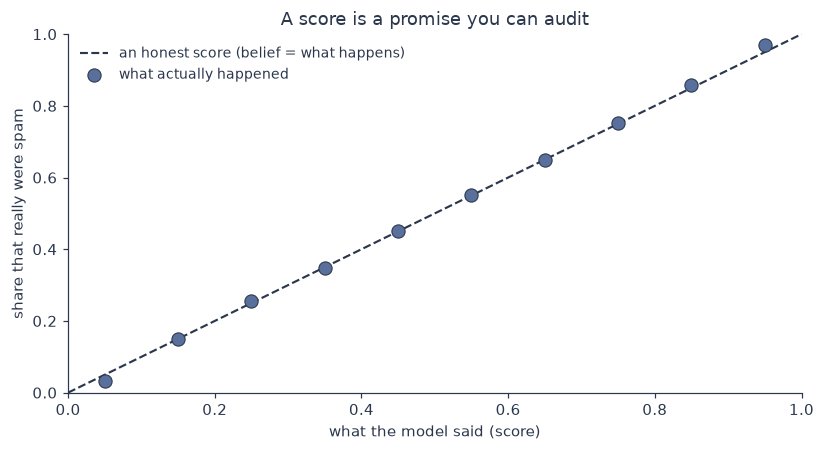

In [3]:
# --- Is "0.87" a real bet? Score 200,000 emails, then go and look at what actually happened.
rng = np.random.default_rng(87)
N_EMAILS = 200_000

# Each email has some true chance of being spam. Beta(0.45, 0.45) is U-shaped: most mail is either
# obviously ham or obviously spam with a thin middle, which is what a real inbox looks like.
true_chance = rng.beta(0.45, 0.45, N_EMAILS)
is_spam = rng.random(N_EMAILS) < true_chance
score = true_chance                      # an honest scorer reports the belief it actually holds

bands = []
for lo in np.arange(0.0, 1.0, 0.1):
    in_band = (score >= lo) & (score < lo + 0.1)
    bands.append({"model said": f"{lo:.1f} – {lo + 0.1:.1f}",
                  "emails": f"{in_band.sum():,}",
                  "actually spam": f"{100 * is_spam[in_band].mean():.1f}%"})
display(pd.DataFrame(bands).set_index("model said"))

narrow = (score > 0.85) & (score < 0.89)
print(f"Emails this model scored between 0.85 and 0.89 : {narrow.sum():,}")
print(f"Share of those that really were spam           : {100 * is_spam[narrow].mean():.1f}%")
print(f"Overall spam rate across all {N_EMAILS:,} emails  : {100 * is_spam.mean():.1f}%\n")
print("So '0.87' means: bet on spam at about 87-to-13 odds. It does not mean 'this email is 87% spam'")
print("and it does not mean 'the model is 87% accurate'. It is a price, and the last column is the payout.")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
centres = np.arange(0.05, 1.0, 0.1)
observed = [is_spam[(score >= c - 0.05) & (score < c + 0.05)].mean() for c in centres]
ax.plot([0, 1], [0, 1], color=VSP["ink"], linestyle="--", linewidth=1.4,
        label="an honest score (belief = what happens)")
ax.scatter(centres, observed, s=75, color=VSP["navy"], edgecolor=VSP["ink"], linewidth=0.7, zorder=3,
           label="what actually happened")
ax.set_xlabel("what the model said (score)")
ax.set_ylabel("share that really were spam")
ax.set_title("A score is a promise you can audit")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### The landing line for the whole program

Every model output is

> **P( answer | inputs, training data )**

Read it right to left. The answer is **conditional** — on the inputs you handed it, and on data somebody
else collected, at some time, from some population, with some labelling process. That is the `LSN-0.2`
question (*how many, and collected how?*) showing up inside a probability.

And here is the trap that costs money: **conditional probabilities do not flip.** P(A | B) is a different
number from P(B | A) — often wildly different — and the rest of this session is one example of *how*
wildly.

## Conditioning, in counts, with no algebra

Back to the payments client's fraud detector. The vendor's line: *"it catches 99% of fraud."*

That sentence is a **conditional**; you just have to notice what it conditions on.

> Of the transactions **that are fraud**, 99 in 100 raise an alert.
> In notation you never need to use again: **P(alert | fraud) = 0.99**.

Below, the same sentence as counts. Nothing here is estimated or simulated — it is the vendor's own claim,
applied to a million transactions.

In [4]:
# --- The forward direction only: of the transactions that ARE fraud, how many alert?
N = 1_000_000              # transactions in the window
BASE_RATE = 1 / 10_000     # fraud occurs in 1 of every 10,000 transactions
SENSITIVITY = 0.99         # of the fraud, 99% raises an alert    <- the vendor's headline
FALSE_POSITIVE_RATE = 0.01 # of the legit, 1% raises an alert too  <- the vendor's small print

fraud = int(N * BASE_RATE)
caught = int(fraud * SENSITIVITY)
missed = fraud - caught

print(f"Of {N:,} transactions, {fraud} are fraud.")
print(f"  raised an alert : {caught}")
print(f"  slipped through : {missed}")
print(f"  -> of the transactions THAT ARE FRAUD, {caught}/{fraud} = {caught / fraud:.0%} alerted.")
print(f"     P(alert | fraud) = {caught / fraud:.2f}. The vendor's claim is true, exactly as stated.\n")
print("Now flip the condition, because the flipped version is the only one an analyst ever needs:")
print()
print("      Of the transactions THAT RAISED AN ALERT, what share are fraud?")
print()
print("Write your number down before you run segment 2. Most rooms say 'about 99%' and some say")
print("'a bit less than 99%'. Both are wrong, and the gap is not small.")

Of 1,000,000 transactions, 100 are fraud.
  raised an alert : 99
  slipped through : 1
  -> of the transactions THAT ARE FRAUD, 99/100 = 99% alerted.
     P(alert | fraud) = 0.99. The vendor's claim is true, exactly as stated.

Now flip the condition, because the flipped version is the only one an analyst ever needs:

      Of the transactions THAT RAISED AN ALERT, what share are fraud?

Write your number down before you run segment 2. Most rooms say 'about 99%' and some say
'a bit less than 99%'. Both are wrong, and the gap is not small.


**Do not read on until you have written a number down.** The session turns on the size of your surprise,
and you only get one shot at it.

Notice what the flip needs that the vendor's sentence never mentioned: **how much fraud there is in the
first place.** That missing ingredient is the **base rate**, and it is the next 25 minutes.

---

# Segment 2 — Base rates: the arithmetic on screen *(25 min)*

*Pre-work check first: go round the room and collect the last line of everybody's counts table. Then build
it together, in counts, one row at a time.*

The same three facts as the one-pager:

| Fact | Value |
|---|---|
| Transactions in the window | **1,000,000** |
| Base rate of fraud | **1 in 10,000** |
| Detector catches (of the fraud) | **99%** |
| False-positive rate (of the legit) | **1%** |

In [5]:
# --- The whole lesson, as a table of whole transactions. No formulas, no Bayes notation.
legit = N - fraud                                   # N, fraud, caught, missed come from segment 1
false_alarms = int(legit * FALSE_POSITIVE_RATE)
cleared = legit - false_alarms
alerts = caught + false_alarms

table = pd.DataFrame(
    {"detector raised an alert": [caught, false_alarms, alerts],
     "detector stayed quiet": [missed, cleared, missed + cleared],
     "row total": [fraud, legit, N]},
    index=["really was fraud", "really was legitimate", "column total"])
display(table.map(lambda v: f"{v:,}"))

precision = caught / alerts
print(f"base rate     : {N:,} / 10,000                     = {fraud:,} fraud, {legit:,} legitimate")
print(f"fraud caught  : {fraud:,} x {SENSITIVITY:.0%}                        = {caught:,}")
print(f"false alarms  : {legit:,} x {FALSE_POSITIVE_RATE:.0%}                  = {false_alarms:,}")
print(f"ALERT QUEUE   : {caught:,} real + {false_alarms:,} false          = {alerts:,} alerts")
print()
print(f"  share of alerts that are really fraud = {caught:,} / {alerts:,} = {precision:.6f}")
print(f"                                        = {100 * precision:.2f}%")
print(f"  i.e. 1 real alert in every {alerts / caught:.0f} alerts.")
print()
print(f"[PASS] A detector that catches {SENSITIVITY:.0%} of fraud hands you a queue that is under 1% real.")
print(f"       Nothing was mis-stated anywhere. P(alert | fraud) = {caught / fraud:.2f}; "
      f"P(fraud | alert) = {precision:.4f}.")
print(f"       They differ by a factor of {(caught / fraud) / precision:.0f}, and the only thing standing")
print("       between them is the base rate.")
print()
print(f"Footnote for whoever is about to say 'but it's 99% accurate': it is. "
      f"({caught:,} + {cleared:,}) / {N:,} = {(caught + cleared) / N:.1%}")
print(f"       Accuracy is dominated by the {legit:,} easy negatives, so it cannot see this problem")
print("       at all — the LSN-0.2 drill, arriving from the other direction.")

# The lesson plan scripts these five numbers. Verify, don't trust.
assert (fraud, caught, false_alarms, alerts) == (100, 99, 9_999, 10_098), "counts drifted from the plan"
assert precision < 0.01, "the plan's 'under 1% of alerts are fraud' must hold"

,detector raised an alert,detector stayed quiet,row total
really was fraud,99,1,100
really was legitimate,"9,999","989,901","999,900"
column total,"10,098","989,902","1,000,000"


base rate     : 1,000,000 / 10,000                     = 100 fraud, 999,900 legitimate
fraud caught  : 100 x 99%                        = 99
false alarms  : 999,900 x 1%                  = 9,999
ALERT QUEUE   : 99 real + 9,999 false          = 10,098 alerts

  share of alerts that are really fraud = 99 / 10,098 = 0.009804
                                        = 0.98%
  i.e. 1 real alert in every 102 alerts.

[PASS] A detector that catches 99% of fraud hands you a queue that is under 1% real.
       Nothing was mis-stated anywhere. P(alert | fraud) = 0.99; P(fraud | alert) = 0.0098.
       They differ by a factor of 101, and the only thing standing
       between them is the base rate.

Footnote for whoever is about to say 'but it's 99% accurate': it is. (99 + 989,901) / 1,000,000 = 99.0%
       Accuracy is dominated by the 999,900 easy negatives, so it cannot see this problem
       at all — the LSN-0.2 drill, arriving from the other direction.


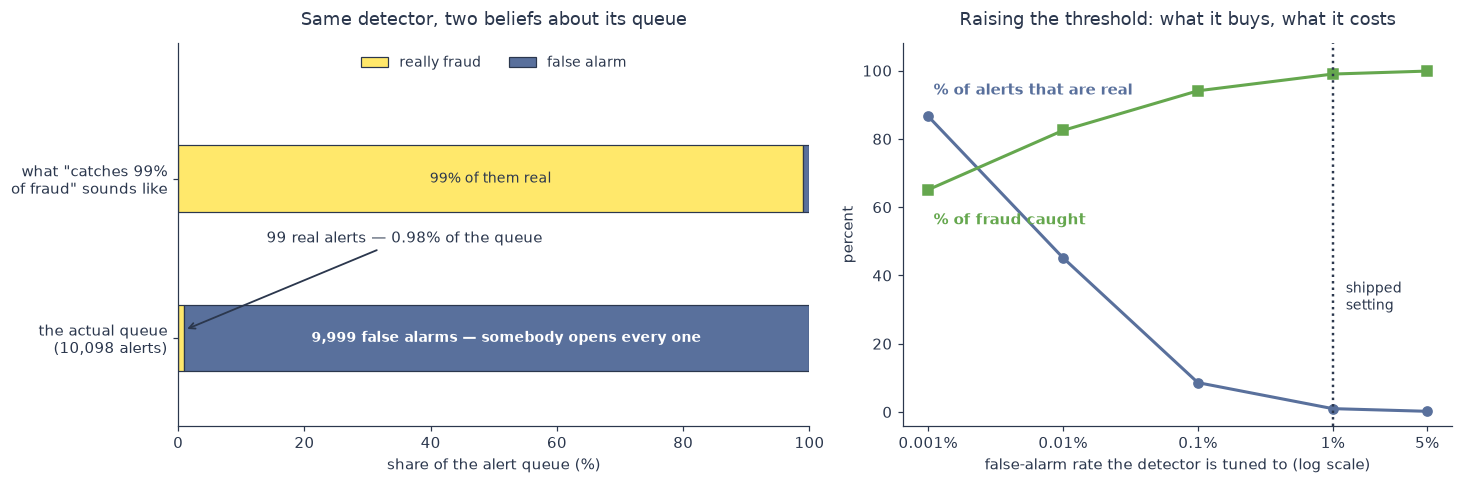

,fraud caught,false alarms,alerts to review,% of alerts real
tuned false-alarm rate,,,,
5%,100 of 100,"49,995","50,095",0.20%
1%,99 of 100,"9,999","10,098",0.98%
0.1%,94 of 100,"1,000","1,094",8.60%
0.01%,82 of 100,100,182,45.20%
0.001%,65 of 100,10,75,86.68%


Sanity check on the 1% row — it has to reproduce the table above: 99 of 100 caught, 9,999 false alarms, 10,098 alerts, 0.98% real.


In [6]:
# --- One picture: what "99% accurate" sounds like, and what the review queue actually holds.
fig, (ax_q, ax_sweep) = plt.subplots(1, 2, figsize=(13.4, 4.5),
                                     gridspec_kw={"width_ratios": [1.15, 1]})

# Left: the alert queue, to scale. The real-fraud sliver is 0.98% of the bar — that IS the lesson.
# y = 1 is the belief (drawn on top), y = 0 is the actual queue.
real_share = [99.0, 100 * precision]
false_share = [1.0, 100 * (1 - precision)]
ax_q.barh([1, 0], real_share, color=VSP["yellow"], edgecolor=VSP["ink"], linewidth=0.8,
          label="really fraud", height=0.42)
ax_q.barh([1, 0], false_share, left=real_share, color=VSP["navy"], edgecolor=VSP["ink"],
          linewidth=0.8, label="false alarm", height=0.42)
ax_q.set_yticks([0, 1])
ax_q.set_yticklabels([f"the actual queue\n({alerts:,} alerts)",
                      'what "catches 99%\nof fraud" sounds like'], fontsize=9.5)
ax_q.set_ylim(-0.55, 1.85)
ax_q.set_xlabel("share of the alert queue (%)")
ax_q.set_xlim(0, 100)
ax_q.set_title("Same detector, two beliefs about its queue", pad=12)
ax_q.legend(loc="upper center", ncol=2, fontsize=9)          # sits in the headroom above the bars
ax_q.annotate(f"{caught} real alerts — {100 * precision:.2f}% of the queue",
              xy=(100 * precision, 0.05), xytext=(14, 0.60), fontsize=9.5, ha="left",
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.2))
ax_q.text(52, 0.0, f"{false_alarms:,} false alarms — somebody opens every one",
          fontsize=9, ha="center", va="center", color="white", fontweight="bold")
ax_q.text(49.5, 1.0, "99% of them real", fontsize=9, ha="center", va="center", color=VSP["ink"])
ax_q.spines[["top", "right"]].set_visible(False)


def phi(x):
    """Standard-normal CDF via the stdlib error function (there is no scipy in this venv)."""
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def phi_inv(p):
    """Inverse standard-normal CDF by bisection — plenty exact for a threshold sweep."""
    lo_, hi_ = -9.0, 9.0
    for _ in range(200):
        mid = 0.5 * (lo_ + hi_)
        lo_, hi_ = (mid, hi_) if phi(mid) < p else (lo_, mid)
    return 0.5 * (lo_ + hi_)


# Right: "raise the threshold" — the option every room suggests first, costed out.
# Model: every transaction gets a risk score. Legit scores ~ Normal(0, 1), fraud ~ Normal(2z*, 1),
# calibrated so the SHIPPED threshold gives exactly 1% false alarms AND exactly 99% of fraud caught.
Z_SHIPPED = phi_inv(1 - FALSE_POSITIVE_RATE)
SEPARATION = 2 * Z_SHIPPED
assert abs((1 - phi(Z_SHIPPED)) - FALSE_POSITIVE_RATE) < 1e-9
assert abs((1 - phi(Z_SHIPPED - SEPARATION)) - SENSITIVITY) < 1e-9

rows, xs, prec_pts, caught_pts = [], [], [], []
for target in (0.05, 0.01, 0.001, 1e-4, 1e-5):
    z = phi_inv(1 - target)
    sens = 1 - phi(z - SEPARATION)
    fa = legit * target
    ct = fraud * sens
    rows.append({"tuned false-alarm rate": f"{100 * target:g}%",
                 "fraud caught": f"{ct:.0f} of {fraud}",
                 "false alarms": f"{fa:,.0f}",
                 "alerts to review": f"{ct + fa:,.0f}",
                 "% of alerts real": f"{100 * ct / (ct + fa):.2f}%"})
    xs.append(100 * target)
    prec_pts.append(100 * ct / (ct + fa))
    caught_pts.append(100 * sens)

ax_sweep.plot(xs, prec_pts, marker="o", color=VSP["navy"], linewidth=2)
ax_sweep.plot(xs, caught_pts, marker="s", color=VSP["green"], linewidth=2)
ax_sweep.axvline(100 * FALSE_POSITIVE_RATE, color=VSP["ink"], linestyle=":", linewidth=1.6)
# Label the two lines where they start, rather than parking a legend on top of them.
ax_sweep.annotate("% of alerts that are real", xy=(0.0011, prec_pts[-1]), xytext=(0.0011, 93),
                  color=VSP["navy"], fontsize=9.5, fontweight="bold")
ax_sweep.annotate("% of fraud caught", xy=(0.0011, caught_pts[-1]), xytext=(0.0011, 55),
                  color=VSP["green"], fontsize=9.5, fontweight="bold")
ax_sweep.text(1.25, 30, "shipped\nsetting", fontsize=9, ha="left", color=VSP["ink"])
ax_sweep.set_xscale("log")
ax_sweep.set_xticks([0.001, 0.01, 0.1, 1, 5])
ax_sweep.set_xticklabels(["0.001%", "0.01%", "0.1%", "1%", "5%"])
ax_sweep.minorticks_off()
ax_sweep.set_xlabel("false-alarm rate the detector is tuned to (log scale)")
ax_sweep.set_ylabel("percent")
ax_sweep.set_title("Raising the threshold: what it buys, what it costs", pad=12)
ax_sweep.set_ylim(-4, 108)
ax_sweep.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(pd.DataFrame(rows).set_index("tuned false-alarm rate"))
print(f"Sanity check on the 1% row — it has to reproduce the table above: {caught} of {fraud} caught, "
      f"{false_alarms:,} false alarms, {alerts:,} alerts, {100 * precision:.2f}% real.")

### Name the quantity

The number you just computed — **the fraction of alerts that are real** — is called **precision**. On the
shipped setting it is **0.98%**.

The other line in the sweep — **the fraction of fraud you catch** — has a name too: **recall**. It is the
99% the vendor sold you.

That is as far as we go today. **`LSN-1.3` — Grading models** gives both of them the formal treatment, with
the confusion matrix you have just drawn by hand, and **it reuses this exact fraud detector** as its worked
example. Today's only job was to make the arithmetic unforgettable.

### Discussion (5 min): what would you actually do?

Three options come up in every room. All three are real and they trade against each other:

| Option | What it buys | What it costs |
|---|---|---|
| **Raise the threshold** | Precision jumps: tuned to a **0.01%** false-alarm rate the queue is **45% real** and holds **182** alerts instead of 10,098 | You now catch **82 of 100** frauds instead of 99. Seventeen more frauds get paid |
| **Improve the features** | The only move that improves both columns at once — better signal separates fraud from legit more sharply | Money, data access and months. It is a project, not a setting |
| **Staff the queue** | Keeps recall at 99% | **10,098** reviews per million transactions, forever. Do that headcount arithmetic in front of the client |

**The pre-sales point:** none of these is a bug report. A base rate of 1 in 10,000 means *somebody is going
to look at a lot of legitimate transactions* — the only questions are how many and who pays. Walking into
that conversation with the counts already done is the difference between a vendor and an advisor.

> **The reflex to leave with:** when anyone quotes a detection rate, ask **"and what's the base rate?"**
> Rare events generate mostly-false alerts. That is why *"our AI flags risky contracts with 95% accuracy"*
> earns a follow-up question rather than a nod.

---

# Segment 3 — Correlation vs causation *(20 min)*

When someone shows you that **A moves with B**, there are exactly **four** explanations — and the chart
cannot tell them apart:

| # | Explanation | Example |
|---|---|---|
| 1 | **A → B** — A really does cause B | the one they are claiming |
| 2 | **B → A** — the arrow points the other way | "support tickets cause churn", vs *churning customers file tickets* |
| 3 | **C → both** — a **confounder** drives both | ice cream and drownings (below) |
| 4 | **Coincidence** — you searched until something fit | 500 metrics, 12 months each (below) |

Three demonstrations follow. In each one **we wrote the data generator**, so we know the true answer — which
is precisely the luxury you never have in a client's data.

312 weeks · temperature 2–27 °C · cones 324–2,764/wk · drownings 0–58/wk (5,087 in total)

correlation(ice cream sales, drownings) = 0.943
In a client deck a 0.94 is a slide, a headline and a recommendation.

correlation WITHIN a single temperature = -0.022
  -> 0.94 collapses to -0.02 once summer is held still.
     The relationship was summer the whole time.


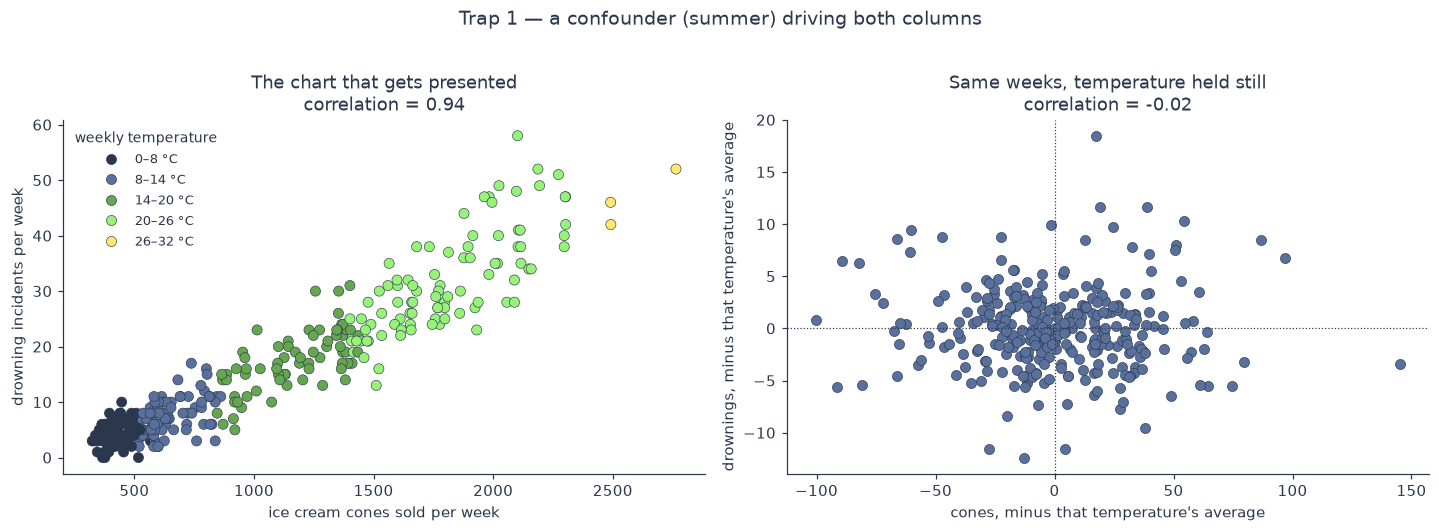

In [7]:
# --- TRAP 1 (confounder). Ice cream sales and drownings: six years of weekly data.
# Both columns are generated from TEMPERATURE ONLY. Neither is allowed to touch the other —
# there is no arrow between them anywhere in this cell.
rng = np.random.default_rng(33)
WEEKS = 312                                                   # six years
week = np.arange(WEEKS)
season = -np.cos(2 * np.pi * (week + 2) / 52.18)              # -1 in January, +1 in July

# Weather arrives rounded to whole degrees, which is what makes the strata below exact.
temp_c = np.rint(14.0 + 9.5 * season + rng.normal(0, 1.6, WEEKS)).astype(int)

# Poisson counts: cones and incidents cannot be negative, and an exponential response to
# temperature keeps every mean positive at any temperature.
cones = rng.poisson(900.0 * np.exp(0.085 * (temp_c - 14)))
drownings = rng.poisson(12.0 * np.exp(0.115 * (temp_c - 14)))

r_naive = np.corrcoef(cones, drownings)[0, 1]
print(f"{WEEKS} weeks · temperature {temp_c.min()}–{temp_c.max()} °C · "
      f"cones {cones.min():,}–{cones.max():,}/wk · drownings {drownings.min()}–{drownings.max()}/wk "
      f"({drownings.sum():,} in total)")
print(f"\ncorrelation(ice cream sales, drownings) = {r_naive:.3f}")
print(f"In a client deck a {r_naive:.2f} is a slide, a headline and a recommendation.\n")

# Hold the confounder still: inside each recorded temperature, subtract that temperature's own
# average from both columns and correlate what is left. That is "controlling for temperature",
# and it is nothing more than arithmetic on groups.
frame = pd.DataFrame({"temp_c": temp_c, "cones": cones, "drownings": drownings})
residual = frame.groupby("temp_c")[["cones", "drownings"]].transform(lambda s: s - s.mean())
r_within = np.corrcoef(residual["cones"], residual["drownings"])[0, 1]
print(f"correlation WITHIN a single temperature = {r_within:+.3f}")
print(f"  -> {r_naive:.2f} collapses to {r_within:+.2f} once summer is held still.")
print("     The relationship was summer the whole time.")

band_edges = [(0, 8), (8, 14), (14, 20), (20, 26), (26, 32)]
band_label = np.full(WEEKS, "", dtype=object)
for lo, hi in band_edges:
    band_label[(temp_c >= lo) & (temp_c < hi)] = f"{lo}–{hi} °C"
frame["band"] = band_label

fig, (ax_raw, ax_res) = plt.subplots(1, 2, figsize=(13.2, 4.7))
order = [f"{lo}–{hi} °C" for lo, hi in band_edges]
palette = {order[0]: VSP["ink"], order[1]: VSP["navy"], order[2]: VSP["green"],
           order[3]: VSP["mint"], order[4]: VSP["yellow"]}
sns.scatterplot(data=frame, x="cones", y="drownings", hue="band", hue_order=order, palette=palette,
                edgecolor=VSP["ink"], linewidth=0.4, s=44, ax=ax_raw)
ax_raw.set_xlabel("ice cream cones sold per week")
ax_raw.set_ylabel("drowning incidents per week")
ax_raw.set_title(f"The chart that gets presented\ncorrelation = {r_naive:.2f}")
ax_raw.legend(title="weekly temperature", fontsize=8.5, title_fontsize=9, loc="upper left")
ax_raw.spines[["top", "right"]].set_visible(False)

ax_res.axhline(0, color=VSP["ink"], linewidth=0.8, linestyle=":")
ax_res.axvline(0, color=VSP["ink"], linewidth=0.8, linestyle=":")
ax_res.scatter(residual["cones"], residual["drownings"], s=44, color=VSP["navy"],
               edgecolor=VSP["ink"], linewidth=0.4)
ax_res.set_xlabel("cones, minus that temperature's average")
ax_res.set_ylabel("drownings, minus that temperature's average")
ax_res.set_title(f"Same weeks, temperature held still\ncorrelation = {r_within:+.2f}")
ax_res.spines[["top", "right"]].set_visible(False)

fig.suptitle("Trap 1 — a confounder (summer) driving both columns", y=1.02, fontsize=12.5)
plt.tight_layout()
plt.show()

**Trap 1 in one sentence:** the cloud on the left is real, reproducible, statistically significant and
completely useless as a basis for action — banning ice cream saves nobody. The confounder was **summer**,
and summer was never a column in the dataset.

The business version is never labelled "summer". It is *the region we launched in first*, *the customers
big enough to have a CSM*, *the quarter the new pricing shipped*.

500 unrelated metrics against one KPI, 12 monthly points each.
True relationship between any of them: none.

  median |correlation|          : 0.223
  strongest |correlation| found  : 0.859   (metric #241, r = +0.859)
  metrics clearing |r| > 0.5     : 55 of 500 (11%)
  metrics clearing |r| > 0.7     : 5 of 500

With 120 months instead of 12: strongest |r| = 0.279, and 0 of 500 clear 0.5.
Small n is what makes the search work. Twelve points is a year of monthly data — which is
exactly the length of chart a client brings to a first meeting.


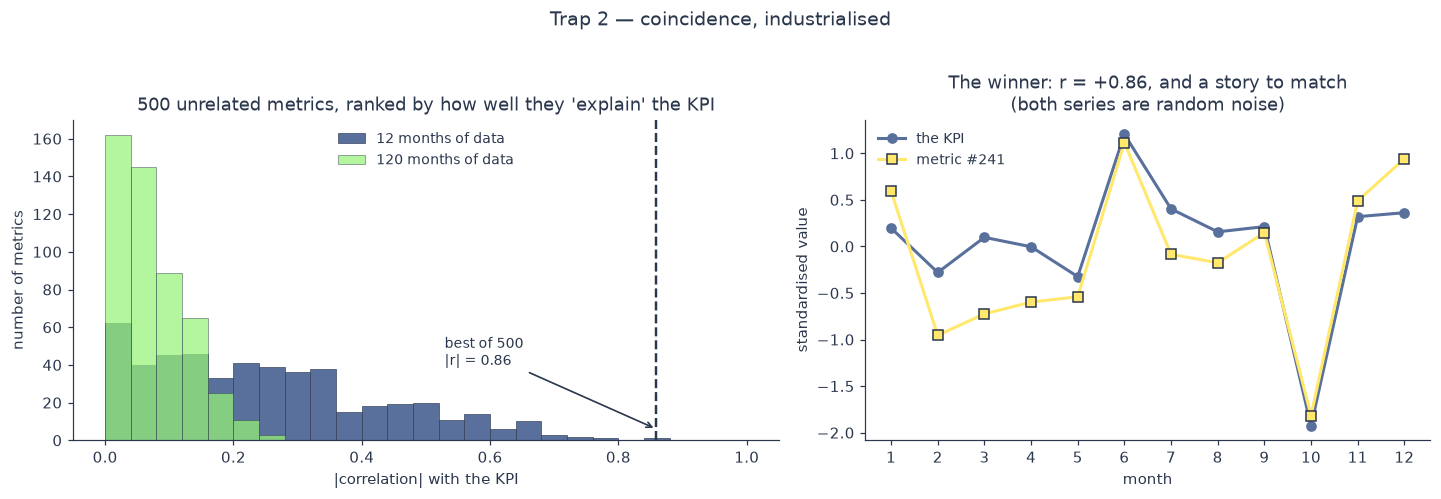

In [8]:
# --- TRAP 2 (coincidence at scale). Twelve months of data, 500 candidate explanations,
# and not one real relationship anywhere in this cell.
rng = np.random.default_rng(1848)
N_MONTHS, N_CANDIDATES = 12, 500

kpi = rng.normal(0, 1, N_MONTHS)                          # "our north-star metric" — pure noise
candidates = rng.normal(0, 1, (N_CANDIDATES, N_MONTHS))   # 500 dashboard metrics — also pure noise
rs = np.array([np.corrcoef(kpi, c)[0, 1] for c in candidates])
best = int(np.argmax(np.abs(rs)))

print(f"{N_CANDIDATES} unrelated metrics against one KPI, {N_MONTHS} monthly points each.")
print("True relationship between any of them: none.\n")
print(f"  median |correlation|          : {np.median(np.abs(rs)):.3f}")
print(f"  strongest |correlation| found  : {np.abs(rs).max():.3f}   "
      f"(metric #{best}, r = {rs[best]:+.3f})")
print(f"  metrics clearing |r| > 0.5     : {(np.abs(rs) > 0.5).sum()} of {N_CANDIDATES} "
      f"({100 * (np.abs(rs) > 0.5).mean():.0f}%)")
print(f"  metrics clearing |r| > 0.7     : {(np.abs(rs) > 0.7).sum()} of {N_CANDIDATES}")

# The same experiment with ten years of monthly data instead of one.
kpi_long = rng.normal(0, 1, 120)
rs_long = np.array([np.corrcoef(kpi_long, c)[0, 1] for c in rng.normal(0, 1, (N_CANDIDATES, 120))])
print(f"\nWith 120 months instead of {N_MONTHS}: strongest |r| = {np.abs(rs_long).max():.3f}, and "
      f"{(np.abs(rs_long) > 0.5).sum()} of {N_CANDIDATES} clear 0.5.")
print("Small n is what makes the search work. Twelve points is a year of monthly data — which is")
print("exactly the length of chart a client brings to a first meeting.")

fig, (ax_hist, ax_best) = plt.subplots(1, 2, figsize=(13.2, 4.4),
                                       gridspec_kw={"width_ratios": [1.25, 1]})
ax_hist.hist(np.abs(rs), bins=np.arange(0, 1.02, 0.04), color=VSP["navy"],
             edgecolor=VSP["ink"], linewidth=0.4, label=f"{N_MONTHS} months of data")
ax_hist.hist(np.abs(rs_long), bins=np.arange(0, 1.02, 0.04), color=VSP["mint"],
             edgecolor=VSP["ink"], linewidth=0.4, alpha=0.72, label="120 months of data")
ax_hist.axvline(np.abs(rs).max(), color=VSP["ink"], linestyle="--", linewidth=1.6)
ax_hist.annotate(f"best of 500\n|r| = {np.abs(rs).max():.2f}", xy=(np.abs(rs).max(), 6),
                 xytext=(np.abs(rs).max() - 0.33, 40), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.1))
ax_hist.set_xlabel("|correlation| with the KPI")
ax_hist.set_ylabel("number of metrics")
ax_hist.set_title("500 unrelated metrics, ranked by how well they 'explain' the KPI")
ax_hist.legend(fontsize=9)
ax_hist.spines[["top", "right"]].set_visible(False)

months = np.arange(1, N_MONTHS + 1)
ax_best.plot(months, kpi, marker="o", color=VSP["navy"], linewidth=2, label="the KPI")
ax_best.plot(months, candidates[best], marker="s", color=VSP["yellow"], markeredgecolor=VSP["ink"],
             linewidth=2, label=f"metric #{best}")
ax_best.set_xlabel("month")
ax_best.set_ylabel("standardised value")
ax_best.set_xticks(months)
ax_best.set_title(f"The winner: r = {rs[best]:+.2f}, and a story to match\n"
                  f"(both series are random noise)")
ax_best.legend(fontsize=9)
ax_best.spines[["top", "right"]].set_visible(False)

fig.suptitle("Trap 2 — coincidence, industrialised", y=1.02, fontsize=12.5)
plt.tight_layout()
plt.show()

**Trap 2 in one sentence:** with twelve data points, **11%** of pure-noise metrics clear |r| > 0.5 — so if
you have a dashboard with hundreds of metrics and you go hunting for what "drives" your KPI, you *will*
find something, guaranteed, and it will mean nothing.

This is the mechanism behind **Tyler Vigen's *Spurious Correlations*** (`tylervigen.com`) — cheese
consumption and bedsheet deaths, that genre. It is funny at the length of a book and expensive at the
length of a roadmap. It is also what "we tested 40 variants and this one won" often is, and what a model
does when it finds a pattern in twelve rows of a client's data.

**The question that catches it:** *"how many other things did you check before this one?"*

20,000 customers · 44% use feature X · overall churn 16.7%

  churn among feature-X users : 12.2%
  churn among everyone else   : 20.3%
  -> feature-X users churn 40% LESS. The marketing claim is arithmetically correct.



,customers,use X,churn | uses X,churn | no X,gap (pts)
health score,,,,,
1,1981,10%,29.3%,32.8%,-3.5
2,1932,14%,28.9%,27.4%,+1.5
3,2000,20%,24.8%,23.7%,+1.1
4,2030,29%,20.4%,20.2%,+0.2
5,2005,36%,16.8%,15.2%,+1.6
6,2028,47%,13.4%,12.6%,+0.9
7,2027,59%,13.0%,11.7%,+1.4
8,2000,69%,8.5%,8.4%,+0.1
9,1964,76%,8.2%,7.1%,+1.1


Headline gap, everyone pooled     : -8.1 percentage points
Average gap at equal health score : +0.2 percentage points

[FAIL] The 40% evaporates. Feature X *marks* engaged customers; it does not make them.
       (Individual rows wobble a few points either way — that is sample size. The wobble is
        biggest where a sub-group is small: only 191 adopters at score 1, and only 357 non-adopters
        at score 10. The size-weighted average across all ten rows is the answer.)


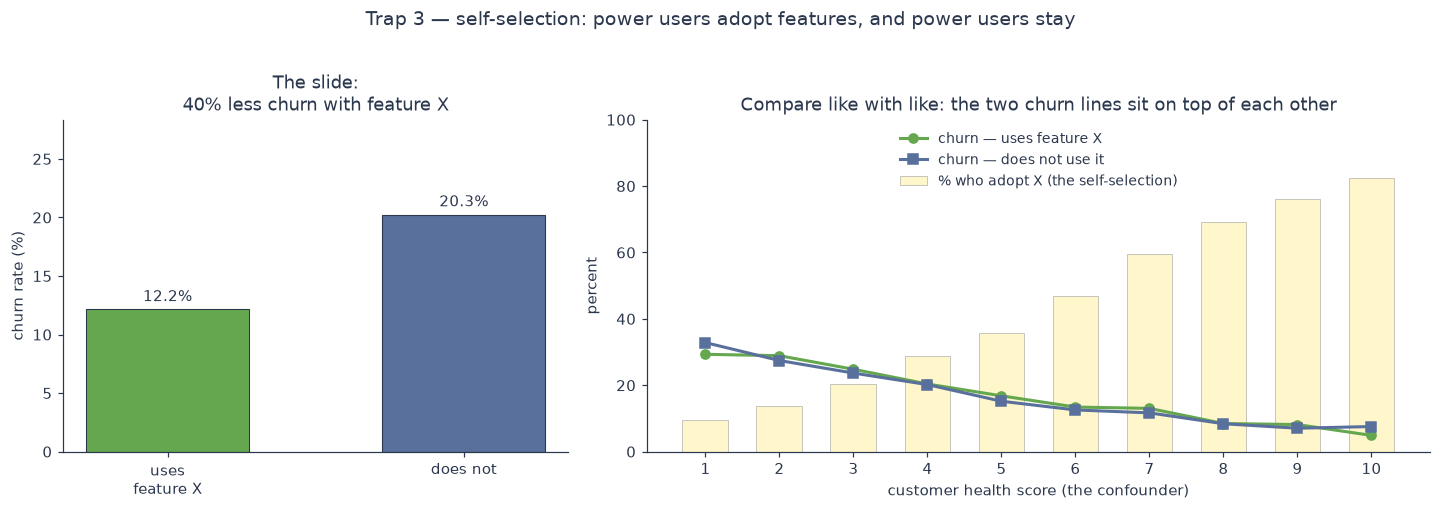

In [9]:
# --- TRAP 3 (self-selection): "customers who use feature X churn 40% less."
# Feature X has EXACTLY ZERO effect on churn in this cell. Churn depends on the health score alone —
# look at p_churn: `uses_x` does not appear in it.
rng = np.random.default_rng(404)
N_CUSTOMERS = 20_000

health = rng.integers(1, 11, N_CUSTOMERS)                      # the product's own 1–10 engagement score
p_adopt = 1 / (1 + np.exp(-(-2.6 + 0.42 * health)))            # engaged customers adopt more features
uses_x = rng.random(N_CUSTOMERS) < p_adopt
p_churn = 1 / (1 + np.exp(-(-0.55 - 0.21 * health)))           # engaged customers churn less. No X here.
churned = rng.random(N_CUSTOMERS) < p_churn

churn_x = churned[uses_x].mean()
churn_no_x = churned[~uses_x].mean()
print(f"{N_CUSTOMERS:,} customers · {uses_x.mean():.0%} use feature X · "
      f"overall churn {churned.mean():.1%}\n")
print(f"  churn among feature-X users : {churn_x:.1%}")
print(f"  churn among everyone else   : {churn_no_x:.1%}")
print(f"  -> feature-X users churn {100 * (1 - churn_x / churn_no_x):.0f}% LESS. "
      f"The marketing claim is arithmetically correct.\n")

# Now compare like with like: customers on the same health score, with X and without.
rows, gaps, weights = [], [], []
for s in range(1, 11):
    same = health == s
    with_x = churned[same & uses_x].mean()
    without_x = churned[same & ~uses_x].mean()
    rows.append({"health score": s, "customers": int(same.sum()),
                 "use X": f"{100 * uses_x[same].mean():.0f}%",
                 "churn | uses X": f"{with_x:.1%}", "churn | no X": f"{without_x:.1%}",
                 "gap (pts)": f"{100 * (with_x - without_x):+.1f}"})
    gaps.append(100 * (with_x - without_x))
    weights.append(same.sum())
display(pd.DataFrame(rows).set_index("health score"))

print(f"Headline gap, everyone pooled     : {100 * (churn_x - churn_no_x):+.1f} percentage points")
print(f"Average gap at equal health score : {np.average(gaps, weights=weights):+.1f} percentage points")
print("\n[FAIL] The 40% evaporates. Feature X *marks* engaged customers; it does not make them.")
print("       (Individual rows wobble a few points either way — that is sample size. The wobble is")
print(f"        biggest where a sub-group is small: only {int((uses_x & (health == 1)).sum())} "
      f"adopters at score 1, and only {int((~uses_x & (health == 10)).sum())} non-adopters")
print("        at score 10. The size-weighted average across all ten rows is the answer.)")

fig, (ax_head, ax_strat) = plt.subplots(1, 2, figsize=(13.2, 4.5),
                                        gridspec_kw={"width_ratios": [1, 1.55]})
bars = ax_head.bar(["uses\nfeature X", "does not"], [100 * churn_x, 100 * churn_no_x],
                   color=[VSP["green"], VSP["navy"]], edgecolor=VSP["ink"], linewidth=0.7, width=0.55)
ax_head.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax_head.set_ylabel("churn rate (%)")
ax_head.set_ylim(0, 100 * churn_no_x * 1.4)
ax_head.set_title(f"The slide:\n{100 * (1 - churn_x / churn_no_x):.0f}% less churn with feature X")
ax_head.spines[["top", "right"]].set_visible(False)

scores = np.arange(1, 11)
ax_strat.bar(scores, [100 * uses_x[health == s].mean() for s in scores], width=0.62,
             color=VSP["yellow"], alpha=0.35, edgecolor=VSP["ink"], linewidth=0.5,
             label="% who adopt X (the self-selection)")
ax_strat.plot(scores, [100 * churned[(health == s) & uses_x].mean() for s in scores],
              marker="o", color=VSP["green"], linewidth=2, label="churn — uses feature X")
ax_strat.plot(scores, [100 * churned[(health == s) & ~uses_x].mean() for s in scores],
              marker="s", color=VSP["navy"], linewidth=2, label="churn — does not use it")
ax_strat.set_xlabel("customer health score (the confounder)")
ax_strat.set_ylabel("percent")
ax_strat.set_xticks(scores)
ax_strat.set_ylim(0, 100)
ax_strat.set_title("Compare like with like: the two churn lines sit on top of each other")
ax_strat.legend(fontsize=9, loc="upper center")
ax_strat.spines[["top", "right"]].set_visible(False)

fig.suptitle("Trap 3 — self-selection: power users adopt features, and power users stay", y=1.02,
             fontsize=12.5)
plt.tight_layout()
plt.show()

### The three traps, and the question that catches each one

| Trap | What you just saw | The question |
|---|---|---|
| **Confounder** | ice cream vs drownings: **r = 0.94 → −0.02** at fixed temperature | *"What else moves with both of these?"* |
| **Coincidence at scale** | 500 noise metrics, 12 months: best |r| = **0.86** | *"How many other things did you check?"* |
| **Self-selection** | feature X: **40% less churn → +0.2 points** at equal health score | *"Who chose to be in that group, and why?"* |

None of these is exotic. All three are the default state of observational business data — which is the only
kind of data a prospect has when they show you a chart in a first meeting.

**Now the drill, where all three arrive at once.**

---

# Segment 4 — Drill: the revenue chart *(20 min)*

## The scenario card

> A retail e-commerce prospect (**~$40M GMV**) wants VSP to expand their "AI success."
>
> The chart: a **recommendation widget launched Nov 3**. **Nov–Dec revenue is +18% vs. Sep–Oct.** The
> widget-adoption curve rises right alongside revenue.
>
> The CTO: ***"The widget drove the 18%. We want you to build phase two."***

**Groups of 3 · 8 minutes · list the questions you would ask.** Then 12 minutes of debrief.

Run the next cell to see the chart the CTO is presenting. Everything on it is true.

2025 GMV       : $40.0M
Sep + Oct 2025 : $7.40M
Nov + Dec 2025 : $8.73M
  -> +18.0% after the Nov 3 launch.   <- the number in the CTO's email

Widget adoption : 6% of sessions in launch week, rising to 41% by the week of Dec 15.
correlation(weekly adoption, weekly revenue) over the 16-week window = 0.92
(the weekly window covers Sep 1 – Dec 21, so it totals $15.29M — the last
 ten days of December fall outside it.)


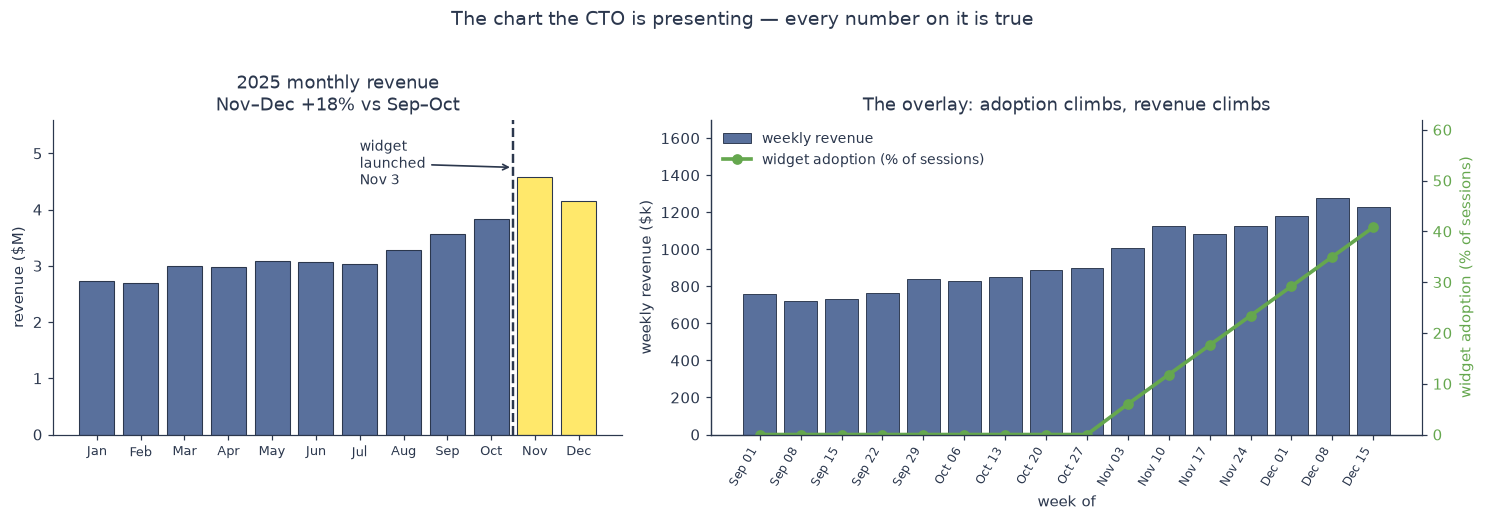

In [10]:
# --- The prospect's data: monthly revenue for two years, plus the widget adoption curve.
# The generator is honest and we read it out loud after the groups report back. For now only
# the chart exists — which is exactly the information a prospect gives you.
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SEASON = np.array([0.78, 0.74, 0.83, 0.84, 0.88, 0.86, 0.84, 0.90, 1.00, 1.06, 1.22, 1.14])
WIDGET_TRUE_EFFECT = 1.03      # <- the truth. Do not read this out until the debrief.
YOY_GROWTH = 1.09              # the business was growing before anybody built a widget

rng = np.random.default_rng(253)
noise_2024 = rng.lognormal(0, 0.022, 12)
noise_2025 = rng.lognormal(0, 0.022, 12)
widget_live = np.arange(12) >= 10                                   # launched Nov 3

raw_2024 = SEASON * noise_2024
raw_2025 = YOY_GROWTH * SEASON * noise_2025 * np.where(widget_live, WIDGET_TRUE_EFFECT, 1.0)
SCALE = 40_000_000 / raw_2025.sum()                                 # 2025 GMV = $40.0M
rev_2024, rev_2025 = raw_2024 * SCALE, raw_2025 * SCALE

sep_oct_25, nov_dec_25 = rev_2025[8:10].sum(), rev_2025[10:12].sum()
lift_2025 = nov_dec_25 / sep_oct_25 - 1

# The adoption curve, weekly, over the window on the CTO's slide (Sep 1 – Dec 21).
rng_wk = np.random.default_rng(1103)
N_WK = 16
WEEK_SHAPE = np.array([0.84, 0.86, 0.88, 0.90, 0.93, 0.96, 0.98, 1.02,
                       1.08, 1.16, 1.32, 1.22, 1.28, 1.34, 1.44, 1.38])
live_wk = np.arange(N_WK) >= 9                                      # Nov 3 begins week 10
adoption = np.where(live_wk, np.clip(0.06 + 0.058 * (np.arange(N_WK) - 9), 0, 0.55), 0.0)
wk_rev = (857_000 * WEEK_SHAPE * np.where(live_wk, WIDGET_TRUE_EFFECT, 1.0)
          * rng_wk.lognormal(0, 0.03, N_WK))
wk_labels = pd.date_range("2025-09-01", periods=N_WK, freq="7D").strftime("%b %d")

print(f"2025 GMV       : ${rev_2025.sum() / 1e6:.1f}M")
print(f"Sep + Oct 2025 : ${sep_oct_25 / 1e6:.2f}M")
print(f"Nov + Dec 2025 : ${nov_dec_25 / 1e6:.2f}M")
print(f"  -> {lift_2025:+.1%} after the Nov 3 launch.   <- the number in the CTO's email\n")
print(f"Widget adoption : {100 * adoption[9]:.0f}% of sessions in launch week, rising to "
      f"{100 * adoption[-1]:.0f}% by the week of {wk_labels[-1]}.")
print(f"correlation(weekly adoption, weekly revenue) over the {N_WK}-week window = "
      f"{np.corrcoef(adoption, wk_rev)[0, 1]:.2f}")
print(f"(the weekly window covers Sep 1 – Dec 21, so it totals ${wk_rev.sum() / 1e6:.2f}M — the last")
print(" ten days of December fall outside it.)")

fig, (ax_m, ax_w) = plt.subplots(1, 2, figsize=(13.6, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})

colours = [VSP["yellow"] if live else VSP["navy"] for live in widget_live]
ax_m.bar(MONTHS, rev_2025 / 1e6, color=colours, edgecolor=VSP["ink"], linewidth=0.7)
ax_m.axvline(9.5, color=VSP["ink"], linestyle="--", linewidth=1.6)
ax_m.annotate("widget\nlaunched\nNov 3", xy=(9.5, 4.75), xytext=(6.0, 4.45), fontsize=9,
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.1))
ax_m.set_ylabel("revenue ($M)")
ax_m.set_ylim(0, 5.6)
ax_m.set_title(f"2025 monthly revenue\nNov–Dec {lift_2025:+.0%} vs Sep–Oct")
ax_m.tick_params(axis="x", labelsize=8.5)
ax_m.spines[["top", "right"]].set_visible(False)

ax_w.bar(range(N_WK), wk_rev / 1e3, color=VSP["navy"], edgecolor=VSP["ink"], linewidth=0.6,
         label="weekly revenue")
ax_w.set_xticks(range(N_WK))
ax_w.set_xticklabels(wk_labels, rotation=60, fontsize=8, ha="right")
ax_w.set_ylabel("weekly revenue ($k)")
ax_w.set_xlabel("week of")
ax_w.set_ylim(0, 1700)
ax_w.spines[["top", "right"]].set_visible(False)

ax_a = ax_w.twinx()
ax_a.plot(range(N_WK), 100 * adoption, color=VSP["green"], marker="o", linewidth=2.4,
          label="widget adoption (% of sessions)")
ax_a.set_ylabel("widget adoption (% of sessions)", color=VSP["green"])
ax_a.tick_params(axis="y", labelcolor=VSP["green"])
ax_a.set_ylim(0, 62)
ax_a.spines[["top"]].set_visible(False)
ax_w.set_title("The overlay: adoption climbs, revenue climbs")
_h = ax_w.get_legend_handles_labels()[0] + ax_a.get_legend_handles_labels()[0]
_l = ax_w.get_legend_handles_labels()[1] + ax_a.get_legend_handles_labels()[1]
ax_w.legend(_h, _l, fontsize=9, loc="upper left")

fig.suptitle("The chart the CTO is presenting — every number on it is true", y=1.02, fontsize=12.5)
plt.tight_layout()
plt.show()

In [11]:
# --- Drill prep (groups of 3, 8 min). What do you ask? Write them as you would say them out loud.
# This cell never fails — it just tells you what is still blank.
MY_QUESTIONS = [
    "",   # 1
    "",   # 2
    "",   # 3
    "",   # 4  (leave blank if you only have three — three sharp ones beat five vague ones)
    "",   # 5
]

_filled = [q.strip() for q in MY_QUESTIONS if len(q.strip()) >= 15]
if len(_filled) < 3:
    print(f"[TODO] {len(_filled)} of at least 3 questions written.")
    print("       Aim at the mechanism, not the statistics. 'Isn't that correlation, not causation?'")
    print("       is not a question — it is a way to end the meeting without learning anything.")
    print("       If the CTO could answer it with 'yes', it isn't a question yet.")
else:
    print(f"[PASS] {len(_filled)} questions ready. Read them out in your group, then rank them:")
    for i, q in enumerate(_filled, start=1):
        print(f"  {i}. {q}")
    print("\n       Which one, answered badly, would kill the phase-two proposal? Lead with that one.")

[TODO] 0 of at least 3 questions written.
       Aim at the mechanism, not the statistics. 'Isn't that correlation, not causation?'
       is not a question — it is a way to end the meeting without learning anything.
       If the CTO could answer it with 'yes', it isn't a question yet.


## Debrief — the instructor list *(12 min)*

Five questions. Groups usually find two or three; the fourth is the one that separates a delivery engineer
from an advisor.

1. **Seasonality** — Nov–Dec *is* the holiday quarter. **What did revenue do last Nov–Dec, without the
   widget?**
2. **What else changed?** — ad spend, promotions, pricing, a site redesign shipping in the same window?
3. **Self-selection** — *who* uses the widget? If engaged buyers click recommendations, the widget **marks**
   good customers rather than making them. (Segment 3, trap 3, in the wild.)
4. **Was there a holdout?** — did any traffic run *without* the widget? Real A/B numbers, or observational
   only?
5. **The denominator** — is that **total** revenue, or revenue *through widget clicks*? Attributed revenue
   often just relabels purchases that would have happened anyway.

Now run the reveal.

In [12]:
# --- The reveal, part 1: question 1, answered. What did the same two months do a year earlier?
sep_oct_24, nov_dec_24 = rev_2024[8:10].sum(), rev_2024[10:12].sum()
lift_2024 = nov_dec_24 / sep_oct_24 - 1
season_only = SEASON[10:12].sum() / SEASON[8:10].sum() - 1

display(pd.DataFrame(
    {"Sep + Oct": [f"${sep_oct_24 / 1e6:.2f}M", f"${sep_oct_25 / 1e6:.2f}M"],
     "Nov + Dec": [f"${nov_dec_24 / 1e6:.2f}M", f"${nov_dec_25 / 1e6:.2f}M"],
     "lift": [f"{lift_2024:+.1%}", f"{lift_2025:+.1%}"],
     "widget live?": ["no — it did not exist", "yes, from Nov 3"]},
    index=["2024", "2025"]))

print(f"2024, no widget, same two months : {lift_2024:+.1%}")
print(f"2025, with the widget            : {lift_2025:+.1%}")
print(f"  -> the calendar alone bought {100 * lift_2024:.0f} of those {100 * lift_2025:.0f} points.\n")

print("And here is the generator, read out loud — the truth you never get in a client's data:")
print(f"  seasonality (Nov+Dec vs Sep+Oct, before anything else) : {season_only:+.1%}")
print(f"  the widget's real causal effect on revenue             : {WIDGET_TRUE_EFFECT - 1:+.1%}")
print(f"  the two together, times a little month-to-month noise  : {lift_2025:+.1%}\n")
print(f"Also true, and worth saying in the meeting: Sep–Oct revenue was already "
      f"{sep_oct_25 / sep_oct_24 - 1:+.1%} year")
print("on year, before the widget existed. The business was growing on its own.\n")

# Questions 3 and 5 in one line: the adoption overlay is a trend, and trends correlate with trends.
r_adoption = np.corrcoef(adoption, wk_rev)[0, 1]
r_counter = np.corrcoef(np.arange(N_WK), wk_rev)[0, 1]
print(f"The overlay, tested: correlation(adoption, weekly revenue)            = {r_adoption:.2f}")
print(f"                     correlation(a counter 1,2,3,...,{N_WK}, weekly revenue) = {r_counter:.2f}")
print("A column that does nothing but count weeks 'explains' the revenue better than the widget does.")
print("Two things that both rise over the same 16 weeks always co-move — the overlay is measuring")
print("the calendar, twice.")

,Sep + Oct,Nov + Dec,lift,widget live?
2024,$6.83M,$7.92M,+16.0%,no — it did not exist
2025,$7.40M,$8.73M,+18.0%,"yes, from Nov 3"


2024, no widget, same two months : +16.0%
2025, with the widget            : +18.0%
  -> the calendar alone bought 16 of those 18 points.

And here is the generator, read out loud — the truth you never get in a client's data:
  seasonality (Nov+Dec vs Sep+Oct, before anything else) : +14.6%
  the widget's real causal effect on revenue             : +3.0%
  the two together, times a little month-to-month noise  : +18.0%

Also true, and worth saying in the meeting: Sep–Oct revenue was already +8.4% year
on year, before the widget existed. The business was growing on its own.

The overlay, tested: correlation(adoption, weekly revenue)            = 0.92
                     correlation(a counter 1,2,3,...,16, weekly revenue) = 0.97
A column that does nothing but count weeks 'explains' the revenue better than the widget does.
Two things that both rise over the same 16 weeks always co-move — the overlay is measuring
the calendar, twice.


Nov–Dec visitors     : 3,980,000  ($8.73M of revenue — the same $8.73M the chart shows)
  saw the widget     : 3,582,806 visitors, $2.2002 revenue per visitor
  holdout, no widget : 397,194 visitors, $2.1329 revenue per visitor

MEASURED WIDGET LIFT : +3.2%   (95% range +0.9% to +5.4%)
true effect in the generator : +3.0%   <- the holdout found it
the CTO's number             : +18.0%   <- 6x too big

That is the whole argument for a counterfactual, in three lines of output. The observational
chart cannot separate 'December' from 'the widget'. A holdout can, it costs 10% of the traffic
for two months, and it is the thing to put in phase two.


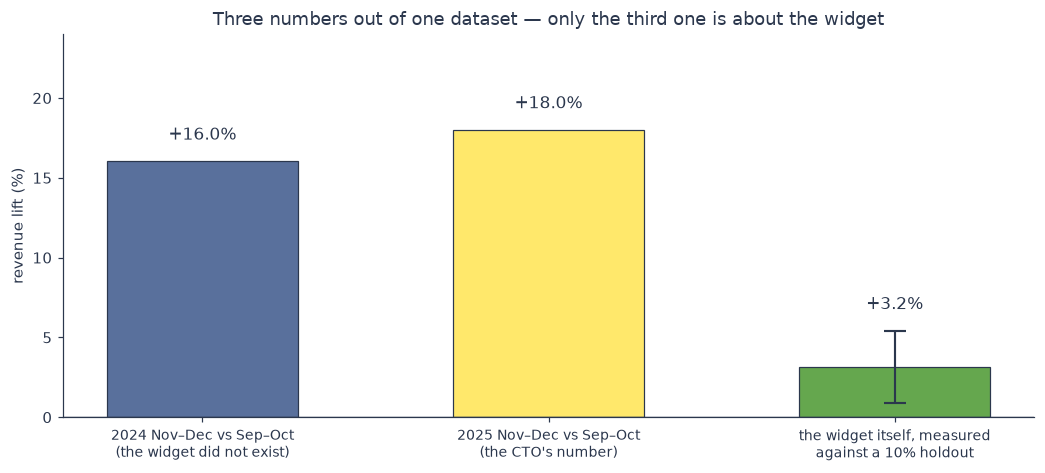

In [13]:
# --- The reveal, part 2: what a holdout would have told them.
# Same world, same widget, same true +3% effect — but 10% of Nov-Dec visitors never see the widget.
rng = np.random.default_rng(1103)
VISITORS = 3_980_000            # Nov-Dec sessions, sized to reproduce the chart's Nov-Dec revenue
HOLDOUT_SHARE = 0.10
BASE_CONVERSION = 0.0250
AOV, AOV_SD = 85.0, 40.0

in_holdout = rng.random(VISITORS) < HOLDOUT_SHARE
conversion = np.where(in_holdout, BASE_CONVERSION, BASE_CONVERSION * WIDGET_TRUE_EFFECT)
ordered = rng.random(VISITORS) < conversion
order_value = np.clip(rng.normal(AOV, AOV_SD, VISITORS), 5, None)
revenue_per_visitor = np.where(ordered, order_value, 0.0)

treated, held = revenue_per_visitor[~in_holdout], revenue_per_visitor[in_holdout]
measured = treated.mean() / held.mean() - 1
se = np.sqrt(treated.var(ddof=1) / treated.size + held.var(ddof=1) / held.size) / held.mean()
lo, hi = measured - 1.96 * se, measured + 1.96 * se

print(f"Nov–Dec visitors     : {VISITORS:,}  (${revenue_per_visitor.sum() / 1e6:.2f}M of revenue — "
      f"the same ${nov_dec_25 / 1e6:.2f}M the chart shows)")
print(f"  saw the widget     : {treated.size:,} visitors, ${treated.mean():.4f} revenue per visitor")
print(f"  holdout, no widget : {held.size:,} visitors, ${held.mean():.4f} revenue per visitor\n")
print(f"MEASURED WIDGET LIFT : {measured:+.1%}   (95% range {lo:+.1%} to {hi:+.1%})")
print(f"true effect in the generator : {WIDGET_TRUE_EFFECT - 1:+.1%}   <- the holdout found it")
print(f"the CTO's number             : {lift_2025:+.1%}   <- {lift_2025 / measured:.0f}x too big\n")
print("That is the whole argument for a counterfactual, in three lines of output. The observational")
print("chart cannot separate 'December' from 'the widget'. A holdout can, it costs 10% of the traffic")
print("for two months, and it is the thing to put in phase two.")

fig, ax = plt.subplots(figsize=(9.6, 4.4))
labels = ["2024 Nov–Dec vs Sep–Oct\n(the widget did not exist)",
          "2025 Nov–Dec vs Sep–Oct\n(the CTO's number)",
          "the widget itself, measured\nagainst a 10% holdout"]
values = [100 * lift_2024, 100 * lift_2025, 100 * measured]
ax.bar(labels, values, color=[VSP["navy"], VSP["yellow"], VSP["green"]],
       edgecolor=VSP["ink"], linewidth=0.8, width=0.55)
# Only the holdout number carries sampling uncertainty worth drawing — the other two are arithmetic.
ax.errorbar([2], [values[2]], yerr=[100 * 1.96 * se], fmt="none", ecolor=VSP["ink"],
            elinewidth=1.4, capsize=7, capthick=1.4)
# Labels placed by hand so the third one clears the top of its error bar.
tops = [values[0], values[1], values[2] + 100 * 1.96 * se]
for x, (v, top) in enumerate(zip(values, tops)):
    ax.text(x, top + 1.1, f"{v:+.1f}%", ha="center", va="bottom", fontsize=11)
ax.axhline(0, color=VSP["ink"], linewidth=0.9)
ax.set_ylabel("revenue lift (%)")
ax.set_ylim(0, 24)
ax.tick_params(axis="x", labelsize=9)
ax.set_title("Three numbers out of one dataset — only the third one is about the widget")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## The punchline

> The only clean answer to *"did it cause the lift?"* is a **counterfactual** — what would have happened
> otherwise. In practice that means a **holdout**. If none exists, **phase two should include one.**

Turning "prove it" into "here's how we'd find out, and it's cheap" is the intelligent-next-question move the
program is built around (`GOAL-1`). **The drill's pass bar is asking for the counterfactual**, not reciting
"correlation isn't causation."

And notice what you did *not* do: you did not tell the CTO he was wrong. The widget really was worth
**+3%** — a good result on $40M of GMV. What was wrong was the **attribution**, and fixing it makes the
client money. That is the `6MAP` translation gap (`GOAL-4`) turning into your value-add: an AI engineer says
*"the model scores 0.93"*, a delivery engineer hears *"93% correct"*, and somebody in that room has to be
the person who asks **conditional on what?**

---

# Homework — three scenario questions

*Async · graded **pass/fail** · reference `LSN-0.3` on submission · feeds `ASM-0`.*

Graded on the reasoning, not the prose. Each question's pass bar is printed below — it is not a secret.

### Question 1 — the churn model
A prospect says: *"our churn model is right 95% of the time."* Their churn rate is **5%**.
**What single question do you ask first, and why might 95% be worth nothing?**

> **Pass:** you name the always-predict-"no churn" baseline, or the class balance.

### Question 2 — the code-review tool
A vendor's chart shows teams using their AI code-review tool ship **30% faster**.
**Give two explanations for the correlation that aren't "the tool causes speed."**

> **Pass:** any two of self-selection, a confounder (team seniority, project type, codebase age),
> reverse causation.

*The vendor's fine print, for what it is worth:* the 30% comes from **40 teams that volunteered for the
beta programme**, compared against the vendor's other customers.

### Question 3 — the security scanner
A security scanner: **98% detection rate**, **3% false-positive rate**; real intrusions hit **1 in 500
sessions**. Out of **50,000 sessions**, roughly **what fraction of alerts are real?**

> **Pass:** you work the counts — about **98** real out of about **1,595** alerts, ≈ **6%**. Arithmetic
> within reason.

Use the workspace cell for scratch work, then fill in the answers cell. It never crashes, and it saves your
submission to `outputs/lsn-0.3/` once everything is filled in.

In [14]:
# --- Your workspace. Nothing in this cell is graded; use it however you like.
#
#  Q1 — 10,000 customers, 5% churn. What accuracy does a model that always says "no churn" get?
#       (One line of arithmetic. Then ask yourself what that model caught.)
#
#  Q3 — 50,000 sessions, 1 intrusion in 500, 98% detected, 3% false-positive rate.
#       Same four rows as segment 2: real intrusions -> detected -> false alarms -> alerts.
#       Heads-up: "3% false-positive rate" can reasonably be read as 3% of the CLEAN sessions or as
#       3% of ALL sessions. Both are accepted below and the answer barely moves — just say which
#       one you used.

In [15]:
# --- Fill in your answers, then run this cell. It never crashes; it tells you what is left to do.

# Question 1 --------------------------------------------------------------------------------
Q1_BASELINE_ACCURACY = None   # accuracy of a model that always predicts "will not churn", as a
                              # fraction (0.95) or a percentage (95) — either is accepted
Q1_FIRST_QUESTION = ""        # the question you ask first, and why 95% might be worth nothing

# Question 2 --------------------------------------------------------------------------------
Q2_EXPLANATION_A = ""         # explanation 1 that is not "the tool causes speed"
Q2_EXPLANATION_B = ""         # explanation 2, of a different KIND from the first

# Question 3 --------------------------------------------------------------------------------
Q3_REAL_INTRUSIONS = None     # of the 50,000 sessions, how many are real intrusions?
Q3_DETECTED = None            # how many of those does the scanner detect?
Q3_FALSE_ALARMS = None        # how many clean sessions raise an alert anyway?
Q3_TOTAL_ALERTS = None        # total alerts in the queue
Q3_FRACTION_REAL = None       # share of alerts that are real: fraction (0.06) or percentage (6)

# ---------------------------------------------------------------- checker (do not edit below)
# stdlib json (submission file), getpass (who), datetime (timestamp)
import json
import getpass
from datetime import datetime, timezone

SESSIONS, INTRUSION_RATE, DETECTION, FPR_Q3 = 50_000, 1 / 500, 0.98, 0.03
_real = SESSIONS * INTRUSION_RATE                       # 100
_detected = _real * DETECTION                           # 98
_fa_clean = (SESSIONS - _real) * FPR_Q3                 # 1,497  (3% of the clean sessions)
_fa_all = SESSIONS * FPR_Q3                             # 1,500  (3% of every session)


def _num(value, targets, tol):
    """True if `value` lands within `tol` of any acceptable reading. Tolerant by design."""
    return value is not None and any(abs(float(value) - float(t)) <= tol for t in targets)


def _share_ok(value, targets, tol):
    """Accept a share given either as a fraction (0.06) or as a percentage (6)."""
    if value is None:
        return False
    v = float(value)
    return any(abs(v - t) <= tol or abs(v - 100 * t) <= 100 * tol for t in targets)


_checks = {
    "Q1_BASELINE_ACCURACY": _share_ok(Q1_BASELINE_ACCURACY, [0.95], 0.005),
    "Q3_REAL_INTRUSIONS": _num(Q3_REAL_INTRUSIONS, [_real], 1),
    "Q3_DETECTED": _num(Q3_DETECTED, [_detected], 1),
    "Q3_FALSE_ALARMS": _num(Q3_FALSE_ALARMS, [_fa_clean, _fa_all], 6),
    "Q3_TOTAL_ALERTS": _num(Q3_TOTAL_ALERTS, [_detected + _fa_clean, _detected + _fa_all], 8),
    "Q3_FRACTION_REAL": _share_ok(Q3_FRACTION_REAL, [_detected / (_detected + _fa_clean),
                                                     _detected / (_detected + _fa_all)], 0.008),
}
_numeric_answers = {"Q1_BASELINE_ACCURACY": Q1_BASELINE_ACCURACY,
                    "Q3_REAL_INTRUSIONS": Q3_REAL_INTRUSIONS, "Q3_DETECTED": Q3_DETECTED,
                    "Q3_FALSE_ALARMS": Q3_FALSE_ALARMS, "Q3_TOTAL_ALERTS": Q3_TOTAL_ALERTS,
                    "Q3_FRACTION_REAL": Q3_FRACTION_REAL}
_texts = {"Q1_FIRST_QUESTION": Q1_FIRST_QUESTION,
          "Q2_EXPLANATION_A": Q2_EXPLANATION_A,
          "Q2_EXPLANATION_B": Q2_EXPLANATION_B}

_blank = [k for k, v in _numeric_answers.items() if v is None]
_off = [k for k, ok in _checks.items() if not ok and k not in _blank]
_short = [k for k, t in _texts.items() if len(t.strip()) < 60]

if _blank or _off or _short:
    if _blank:
        print(f"[TODO] Still None: {', '.join(_blank)}")
    if _short:
        print(f"[TODO] Needs a real answer (60+ characters): {', '.join(_short)}")
    if _off:
        print(f"[CHECK] These don't match the scenario — rework them in the workspace cell: "
              f"{', '.join(_off)}")
    print("\n       Nothing is saved until the above is clear. Re-run this cell when you've fixed it.")
else:
    _frac = float(Q3_FRACTION_REAL)
    _frac = _frac if _frac <= 1 else _frac / 100
    _q1 = float(Q1_BASELINE_ACCURACY)
    _q1 = _q1 if _q1 <= 1 else _q1 / 100
    submission = {
        "lesson": "LSN-0.3", "serves": ["OUT-0.3", "OUT-0.4"], "assessment": "ASM-0",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "q1_churn_model": {"baseline_accuracy": _q1, "first_question": Q1_FIRST_QUESTION.strip()},
        "q2_code_review_tool": {"explanation_a": Q2_EXPLANATION_A.strip(),
                                "explanation_b": Q2_EXPLANATION_B.strip()},
        "q3_security_scanner": {"real_intrusions": float(Q3_REAL_INTRUSIONS),
                                "detected": float(Q3_DETECTED),
                                "false_alarms": float(Q3_FALSE_ALARMS),
                                "total_alerts": float(Q3_TOTAL_ALERTS),
                                "fraction_of_alerts_real": _frac},
    }
    out_dir = REPO_ROOT / "outputs" / "lsn-0.3"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"homework_{getpass.getuser()}.json"
    out_path.write_text(json.dumps(submission, indent=2))

    print("[PASS] Arithmetic checks out.")
    print(f"       Q1: a model that never predicts churn is right {100 * _q1:.0f}% of the time and "
          f"catches nobody.")
    print(f"       Q3: about {float(Q3_DETECTED):.0f} real intrusions inside a queue of "
          f"{float(Q3_TOTAL_ALERTS):,.0f} alerts — {100 * _frac:.1f}% real.")
    print(f"[SAVED] {out_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Submit by referencing LSN-0.3. Graded on the reasoning, not the code.\n")
    print("       Self-check against the pass bars, since they were never secret:")
    print("        Q1 — did you name the always-say-'no churn' baseline, or the class balance?")
    print("        Q2 — are your two explanations of DIFFERENT kinds (self-selection / confounder /")
    print("             reverse causation)? Two versions of 'good teams adopt it' is one explanation.")
    print("        Q3 — did you work it in counts, rather than multiplying two percentages together?")
    _kinds = {
        "self-selection": ("self-select", "selection", "volunteer", "opt in", "opt-in", "chose",
                           "choose", "beta", "already"),
        "confounder": ("confound", "senior", "junior", "experience", "project type", "codebase",
                       "third", "common cause", "both"),
        "reverse causation": ("reverse", "other way", "backwards", "already fast", "fast teams"),
    }
    _blob = (Q2_EXPLANATION_A + " " + Q2_EXPLANATION_B).lower()
    _hit = sorted(name for name, words in _kinds.items() if any(w in _blob for w in words))
    print(f"\n       [advisory only — this does not affect your save] your Q2 wording looks like it")
    print(f"       covers: {', '.join(_hit) if _hit else 'none of the three named kinds — worth a re-read'}")

[TODO] Still None: Q1_BASELINE_ACCURACY, Q3_REAL_INTRUSIONS, Q3_DETECTED, Q3_FALSE_ALARMS, Q3_TOTAL_ALERTS, Q3_FRACTION_REAL
[TODO] Needs a real answer (60+ characters): Q1_FIRST_QUESTION, Q2_EXPLANATION_A, Q2_EXPLANATION_B

       Nothing is saved until the above is clear. Re-run this cell when you've fixed it.


---

## Wrap-up

**You can now, on demand:**

- read any model output as **P(answer | inputs, training data)** — and say out loud what it is conditional
  on;
- run a **base-rate** check in counts, in your head, in a meeting: *1,000,000 → 100 fraud → 99 caught →
  9,999 false alarms → 10,098 alerts → 0.98% real*;
- name the fraction of alerts that are real (**precision**) and explain why a **99%** detection rate does
  not imply it;
- meet "A moves with B" with the **four explanations** — A→B, B→A, confounder, coincidence — and the
  question that catches each;
- answer a causal claim by asking for the **counterfactual**: *was there a holdout, and if not, can phase
  two include one?*

**Next — `LSN-0.4` Deterministic, probabilistic, stochastic** (1 h). Pre-work, ~20 min: re-read the keywords
section of the ML literacy deck and **write one example of each term from your own project experience** —
one thing that is deterministic, one probabilistic, one stochastic. That session is where "the model scores
0.93" and "the answer changed between runs" stop being surprises.

`LSN-0.3` is where `LSN-0.2`'s *"which mistakes make up the missing 8%?"* got its arithmetic.
**`LSN-1.3` — Grading models** is where it gets its vocabulary — and it reuses this fraud detector, so keep
the counts table.